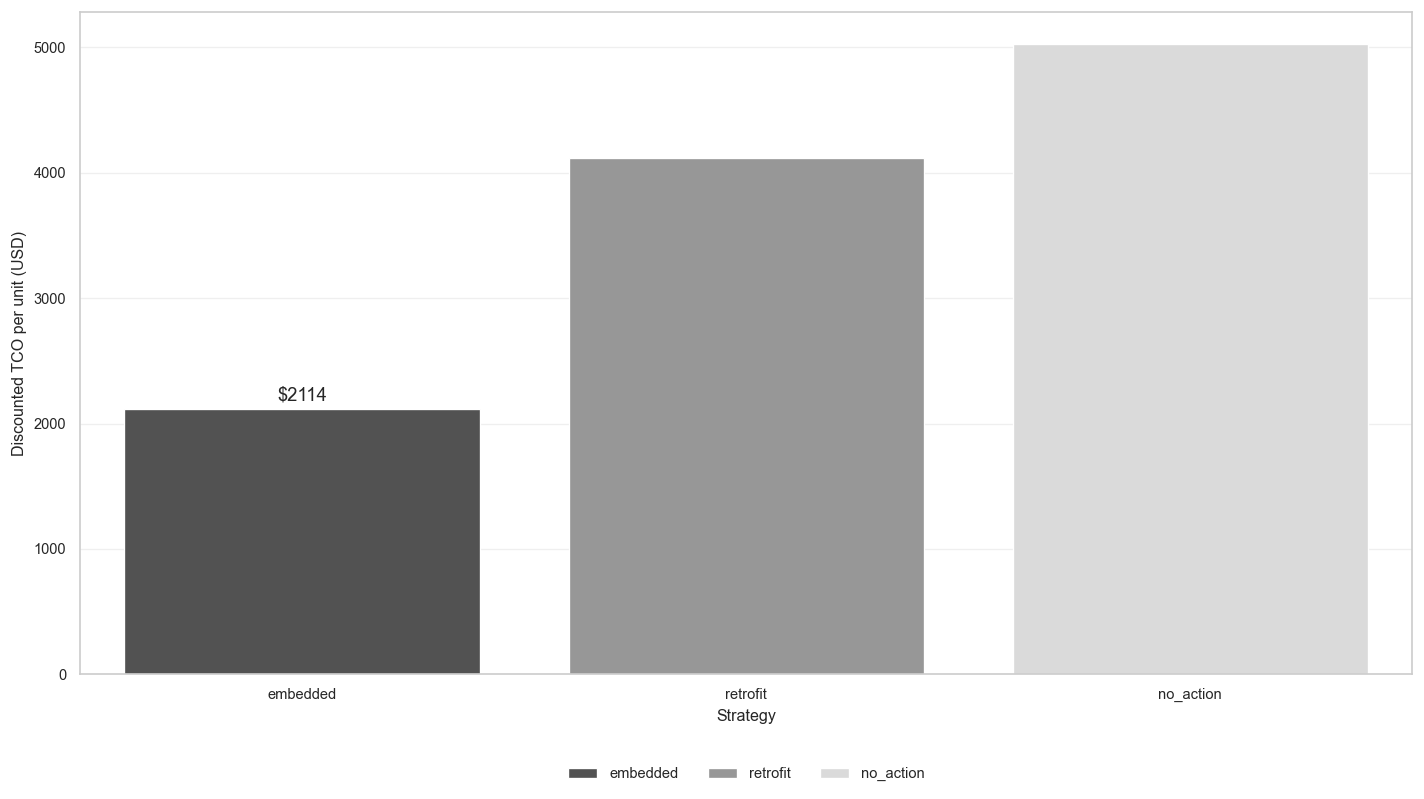

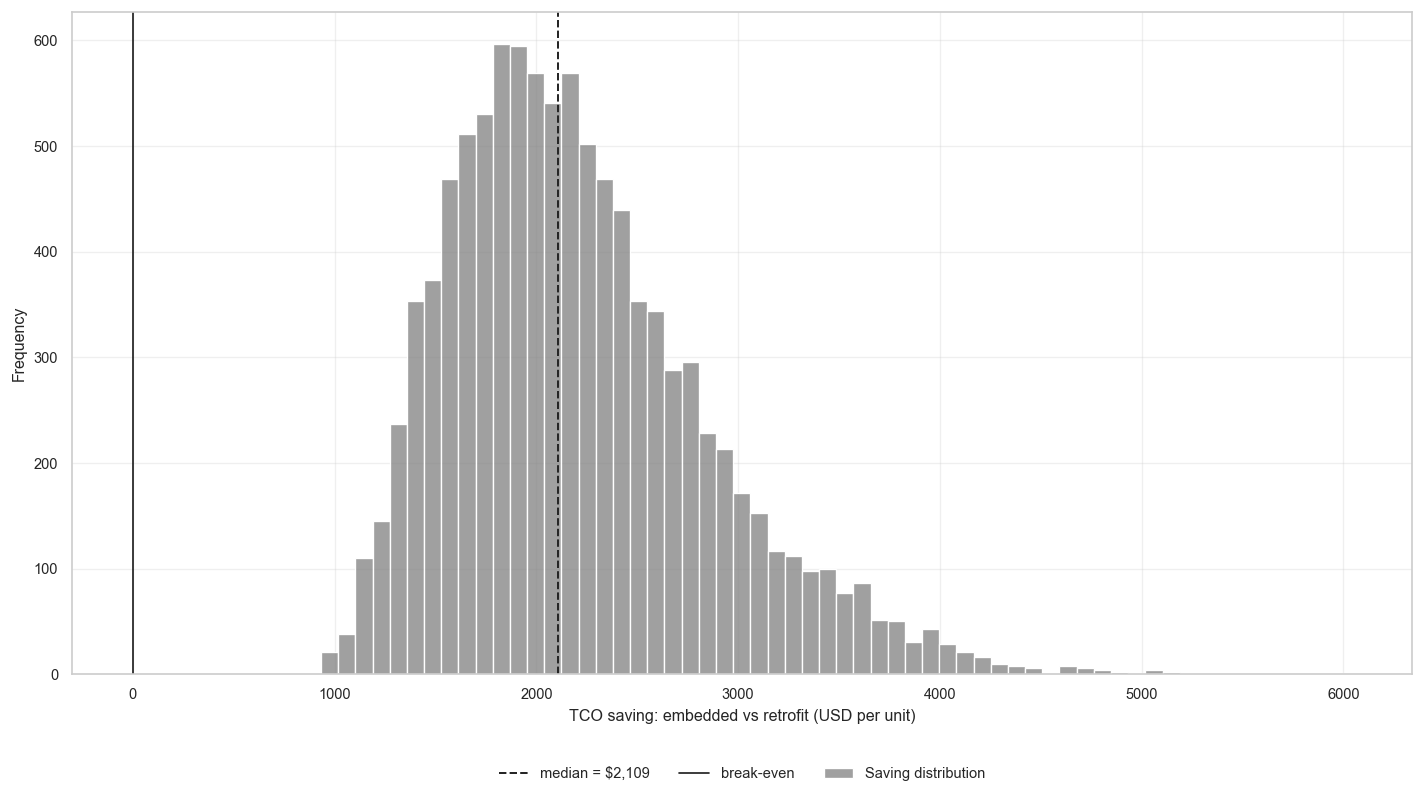

In [2]:
# ============================================================
# 01_cost_benefit_simulation.ipynb
# Cell 1 — Imports, paths, and global configuration
# ============================================================
# Purpose: set up the analysis environment, define reproducible
# input/output paths, and fix the random seed so that every run
# of this notebook produces identical figures and tables.

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility: a fixed seed keeps the Monte Carlo sensitivity
# analysis (Cell 6) identical across runs.
RNG = np.random.default_rng(seed=42)

# Project paths. This notebook lives in leak-iot-study/notebooks/,
# so data and results are one level up.
BASE_DIR    = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR    = BASE_DIR / "data"
FIG_DIR     = BASE_DIR / "results" / "figures"
TABLE_DIR   = BASE_DIR / "results" / "tables"

for d in (FIG_DIR, TABLE_DIR):
    d.mkdir(parents=True, exist_ok=True)

# Global figure style: seaborn, grayscale, 16:9, high-resolution export.
sns.set_theme(style="whitegrid", context="paper")
sns.set_palette("Greys")
plt.rcParams.update({
    "figure.dpi": 120,      # on-screen preview
    "savefig.dpi": 600,     # exported files
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.3,
})
FIGSIZE = (12, 6.75)        # 16:9 aspect ratio

def save_fig(fig, stem: str):
    """Save a figure to results/figures/ as both PNG and PDF at 600 dpi."""
    for ext in ("png", "pdf"):
        fig.savefig(FIG_DIR / f"{stem}.{ext}", dpi=600, bbox_inches="tight")


# ============================================================
# Cell 2 — Load the parameter table (primary-source values)
# ============================================================
# Purpose: load data/parameters.csv, which stores every numeric
# input together with its unit and primary-source citation. Keeping
# citations in the data file (not hard-coded here) preserves the
# audit trail required for a reproducible, review-ready paper.

params = pd.read_csv(DATA_DIR / "parameters.csv")

def get_param(param_id: str) -> float:
    """Return the numeric value of a parameter by its param_id."""
    row = params.loc[params["param_id"] == param_id, "value"]
    if row.empty:
        raise KeyError(f"param_id not found: {param_id}")
    return float(row.iloc[0])

# Display the loaded table so the reader can see provenance inline.
params[["param_id", "parameter", "value", "unit", "source_citation"]]


# ============================================================
# Cell 3 — Scenario assumptions (EVIDENCE-GROUNDED)
# ============================================================
# Purpose: define the three strategies with parameters derived from
# the cited literature in data/parameters.csv, rather than arbitrary
# placeholders. Each derived value notes its source param_id.
#
# Effectiveness anchor: a controlled loss-correlation study (p21/p22,
# LexisNexis 2020) found a 96% reduction in escape-of-water claim
# frequency for homes with smart shutoff. We treat this as the upper
# bound for a fully covered EMBEDDED system, derated for real-world
# coverage; RETROFIT is derated further to reflect the access limits
# and partial coverage inherent to post-construction installation.
#
# Strategies:
#   (a) no_action  — no detection; full exposure to damage costs
#   (b) retrofit   — sensors installed AFTER construction (higher install
#                    cost, lower coverage/effectiveness)
#   (c) embedded   — sensors embedded AT the design stage (lower install
#                    cost per point, higher coverage/effectiveness)

HORIZON_YEARS = 30          # asset life cycle considered
DISCOUNT_RATE = 0.03        # annual discount rate for NPV

# --- Baseline annual water-damage loss per unit (no detection) ---
# p06: average claim USD 15,400; p07: ~1 in 60 homes/yr incident rate.
ANNUAL_INCIDENT_PROB = 1 / 60               # p07
CLAIM_COST           = get_param("p06")     # p06
BASELINE_ANNUAL_LOSS = ANNUAL_INCIDENT_PROB * CLAIM_COST

# --- Effectiveness (fraction of baseline loss avoided) ---
# p21: 96% frequency reduction under ideal, fully-covered conditions.
# Coverage derates below are MODELLING ASSUMPTIONS (state them as such
# in the paper); vary them in the Cell 6 sensitivity analysis.
FREQ_REDUCTION_IDEAL = get_param("p21") / 100.0   # p21 = 96% -> 0.96
COVERAGE_EMBEDDED    = 0.85   # design-stage: near-complete pipe coverage
COVERAGE_RETROFIT    = 0.60   # post-hoc: limited access, partial coverage
EFF_EMBEDDED = FREQ_REDUCTION_IDEAL * COVERAGE_EMBEDDED   # ~0.816
EFF_RETROFIT = FREQ_REDUCTION_IDEAL * COVERAGE_RETROFIT   # ~0.576

# --- Install cost (USD per unit) ---
# Anchored to a nominal embedded cost, with retrofit scaled up by the
# access-driven premium. p20 (wireless vs wired labor ~4x) and general
# retrofit-premium evidence (p17-p19) motivate a retrofit multiplier > 1.
INSTALL_EMBEDDED    = 600.0                 # nominal design-stage install
RETROFIT_MULTIPLIER = 2.0                   # access/labor premium (see p17-p20)
INSTALL_RETROFIT    = INSTALL_EMBEDDED * RETROFIT_MULTIPLIER

# --- Annual O&M (USD per unit) ---
OM_EMBEDDED = 30.0
OM_RETROFIT = 40.0

SCENARIOS = {
    "no_action": dict(install_cost=0.0,
                      annual_om=0.0,
                      loss_avoided=0.00),
    "retrofit":  dict(install_cost=INSTALL_RETROFIT,
                      annual_om=OM_RETROFIT,
                      loss_avoided=EFF_RETROFIT),
    "embedded":  dict(install_cost=INSTALL_EMBEDDED,
                      annual_om=OM_EMBEDDED,
                      loss_avoided=EFF_EMBEDDED),
}


# ============================================================
# Cell 4 — Life-cycle cost model (TCO via discounted cash flow)
# ============================================================
# Purpose: compute the total cost of ownership (TCO) for each strategy
# as the net present value of install cost + annual O&M + residual
# (non-avoided) water-damage loss over the asset horizon.

def discounted_tco(install_cost, annual_om, loss_avoided,
                   baseline_loss=BASELINE_ANNUAL_LOSS,
                   horizon=HORIZON_YEARS, rate=DISCOUNT_RATE):
    """Return discounted TCO (USD, present value) for one strategy."""
    residual_loss = baseline_loss * (1.0 - loss_avoided)
    annual_flow   = annual_om + residual_loss          # recurring yearly cost
    years         = np.arange(1, horizon + 1)
    discount      = 1.0 / (1.0 + rate) ** years
    return install_cost + np.sum(annual_flow * discount)

rows = []
for name, s in SCENARIOS.items():
    tco = discounted_tco(**s)
    rows.append(dict(strategy=name, tco_usd=round(tco, 2),
                     install=s["install_cost"], loss_avoided=round(s["loss_avoided"], 3)))

tco_df = pd.DataFrame(rows).sort_values("tco_usd").reset_index(drop=True)

# Savings versus the no-action baseline.
baseline_tco = tco_df.loc[tco_df["strategy"] == "no_action", "tco_usd"].iloc[0]
tco_df["savings_vs_no_action"] = (baseline_tco - tco_df["tco_usd"]).round(2)

tco_df


# ============================================================
# Cell 5 — Figure: TCO comparison across strategies
# ============================================================
# Purpose: visualise discounted TCO by strategy (seaborn, grayscale,
# 16:9) and save to results/figures/ as PNG + PDF at 600 dpi.
# The legend is placed below the axes so it never overlaps the bars.

fig, ax = plt.subplots(figsize=FIGSIZE)
order = tco_df.sort_values("tco_usd")
sns.barplot(data=order, x="strategy", y="tco_usd",
            hue="strategy", palette="Greys_r", legend=True, ax=ax)
ax.set_ylabel("Discounted TCO per unit (USD)")
ax.set_xlabel("Strategy")
ax.bar_label(ax.containers[0], fmt="$%.0f", padding=3)
sns.move_legend(ax, "upper center", bbox_to_anchor=(0.5, -0.12),
                ncol=3, frameon=False, title=None)

fig.tight_layout()
save_fig(fig, "fig01_tco_comparison")
plt.show()


# ============================================================
# Cell 6 — Sensitivity analysis (Monte Carlo)
# ============================================================
# Purpose: TCO depends on uncertain inputs (incident probability,
# claim cost, coverage-derated effectiveness). We draw N random
# samples for these inputs and report the distribution of the
# embedded-vs-retrofit saving, so the conclusion is not tied to a
# single point estimate. The coverage derates from Cell 3 are the
# key modelling assumptions being stress-tested here.

N = 10_000

# Triangular / normal draws around the point assumptions (illustrative ranges).
incident_prob = RNG.triangular(1/120, 1/60, 1/30, size=N)     # annual P(incident)
claim_cost    = RNG.normal(CLAIM_COST, CLAIM_COST * 0.20, N)  # +/-20% on claim
claim_cost    = np.clip(claim_cost, 1_000, None)

# Effectiveness = ideal frequency reduction (p21) x sampled coverage.
cov_embedded  = RNG.triangular(0.75, 0.85, 0.95, size=N)      # embedded coverage
cov_retrofit  = RNG.triangular(0.45, 0.60, 0.75, size=N)      # retrofit coverage
eff_embedded  = FREQ_REDUCTION_IDEAL * cov_embedded
eff_retrofit  = FREQ_REDUCTION_IDEAL * cov_retrofit

def tco_vec(install, om, loss_avoided, base_loss):
    """Vectorised discounted TCO over Monte Carlo draws."""
    residual = base_loss * (1.0 - loss_avoided)
    annual   = om + residual
    years    = np.arange(1, HORIZON_YEARS + 1)
    discount = 1.0 / (1.0 + DISCOUNT_RATE) ** years
    return install + annual * discount.sum()

base_loss = incident_prob * claim_cost
tco_embedded = tco_vec(INSTALL_EMBEDDED, OM_EMBEDDED, eff_embedded, base_loss)
tco_retrofit = tco_vec(INSTALL_RETROFIT, OM_RETROFIT, eff_retrofit, base_loss)

saving = tco_retrofit - tco_embedded   # positive => embedded is cheaper

summary = pd.Series({
    "mean_saving_usd":   saving.mean(),
    "median_saving_usd": np.median(saving),
    "p05_saving_usd":    np.percentile(saving, 5),
    "p95_saving_usd":    np.percentile(saving, 95),
    "prob_embedded_cheaper": (saving > 0).mean(),
}).round(2)
summary


# ============================================================
# Cell 7 — Figure: distribution of embedded-vs-retrofit saving
# ============================================================
# Purpose: plot the Monte Carlo distribution of the per-unit saving
# from embedding rather than retrofitting (seaborn, grayscale, 16:9),
# mark the median and break-even, and save as PNG + PDF at 600 dpi.
# The legend sits below the axes to avoid overlapping the histogram.

fig, ax = plt.subplots(figsize=FIGSIZE)
sns.histplot(saving, bins=60, ax=ax, color="0.5", label="Saving distribution")
ax.axvline(np.median(saving), linestyle="--", color="0.15",
           label=f"median = ${np.median(saving):,.0f}")
ax.axvline(0, color="k", linewidth=1, label="break-even")
ax.set_xlabel("TCO saving: embedded vs retrofit (USD per unit)")
ax.set_ylabel("Frequency")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12),
          ncol=3, frameon=False)

fig.tight_layout()
save_fig(fig, "fig02_sensitivity_saving")
plt.show()


# ============================================================
# Cell 8 — Export result tables
# ============================================================
# Purpose: write the TCO comparison and the sensitivity summary to
# results/tables/ as CSV files for the manuscript and for archival
# reproducibility.

tco_df.to_csv(TABLE_DIR / "table01_tco_by_strategy.csv", index=False)
summary.to_frame(name="value").to_csv(TABLE_DIR / "table02_sensitivity_summary.csv")